# Hledání nejkratší cesty v bludišti — ukázky

Tento notebook ukazuje použití knihovny `knihovna`: načtení bludiště, nalezení
nejkratší cesty, vykreslení obrázku a generování nových bludišť.

Předpokládá se, že je balíček nainstalovaný (`pip install .` v kořenu projektu).

In [7]:
import os

if os.path.basename(os.getcwd()) == "examples":
    os.chdir("..")
print("Pracovní složka:", os.getcwd())

from knihovna import Bludiste, nacti_bludiste, vygeneruj_bludiste
from IPython.display import Image

Pracovní složka: /home/bel0153/vvp_bludiste


## 1. Načtení a vykreslení bludiště

CSV soubor obsahuje čísla oddělená čárkami (1 = zeď, 0 = volno). Funkce
`nacti_bludiste` ho načte a z mřížky vytvoří objekt `Bludiste`.

Bludiště 20x20


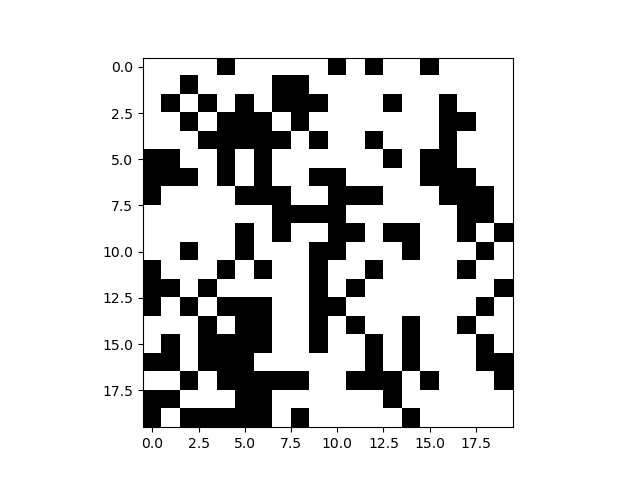

In [8]:
mrizka = nacti_bludiste("data/maze_3.csv")
b = Bludiste(mrizka)
print(b)

b.uloz_obrazek("examples/obrazky/vystup_bezcesty.png")   # bez cesty
Image("examples/obrazky/vystup_bezcesty.png")

## 2. Nalezení nejkratší cesty

Metoda `najdi_cestu` vrátí seznam souřadnic cesty (nebo `None`). Cestu předá
do `uloz_obrazek`, aby se vykreslila červeně.

Délka nejkratší cesty: 41 buněk
Vstup: (0, 0)  Výstup: (19, 19)


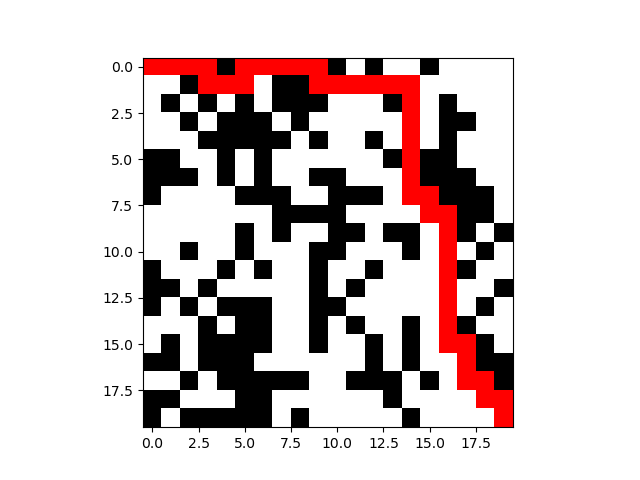

In [3]:
cesta = b.najdi_cestu()
print("Délka nejkratší cesty:", len(cesta), "buněk")
print("Vstup:", cesta[0], " Výstup:", cesta[-1])

b.uloz_obrazek("examples/obrazky/vystup_scestou.png", cesta)
Image("examples/obrazky/vystup_scestou.png")

## 3. Jak hledání funguje uvnitř (dva kroky)

Nejprve se bludiště převede na graf (matice sousednosti), poté se v grafu
najde nejkratší cesta pomocí BFS. Oba kroky lze ukázat samostatně.

In [4]:
from knihovna import graf

# Krok 1: matice sousednosti
matice, cisla_bunek = graf.sestav_matici_sousednosti(b.mrizka)
print("Počet vrcholů (volných buněk):", matice.shape[0])
print("Počet uložených hran:", matice.nnz)

# Krok 2: BFS mezi rohy
start = cisla_bunek[0, 0]
cil = cisla_bunek[-1, -1]
cesta_cisla = graf.nejkratsi_cesta(matice, start, cil)
print("Počet vrcholů na cestě:", len(cesta_cisla))

Počet vrcholů (volných buněk): 254
Počet uložených hran: 636
Počet vrcholů na cestě: 41


## 4. Přehled všech testovacích bludišť

Délky nejkratších cest ve všech pěti testovacích bludištích.

In [5]:
for cislo in range(1, 6):
    bb = Bludiste(nacti_bludiste(f"data/maze_{cislo}.csv"))
    cesta = bb.najdi_cestu()
    print(f"maze_{cislo}: {bb} -> délka cesty: {len(cesta)}")

maze_1: Bludiště 20x20 -> délka cesty: 39
maze_2: Bludiště 20x20 -> délka cesty: 89
maze_3: Bludiště 20x20 -> délka cesty: 41
maze_4: Bludiště 20x20 -> délka cesty: 55
maze_5: Bludiště 31x31 -> délka cesty: 147


## 5. Generování bludišť

`vygeneruj_bludiste` vytvoří náhodné bludiště, které má vždy řešení. Parametry
jsou rozměr, název šablony (`prazdna` nebo `slalom`) a hustota zdí.

Vygenerováno: Bludiště 30x30 -> průchozí: True


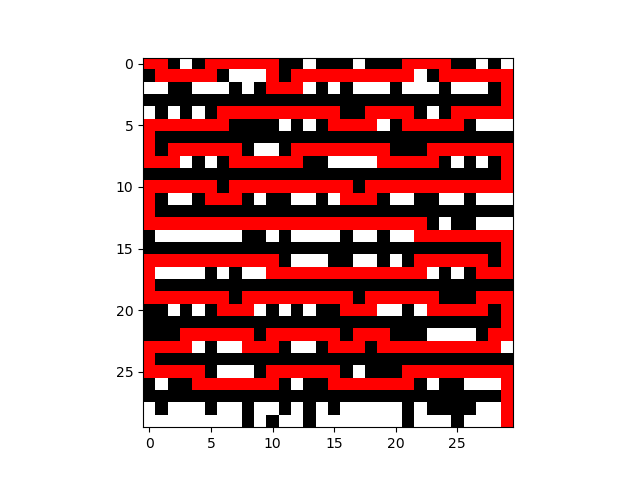

In [9]:
mrizka_slalom = vygeneruj_bludiste(30, "slalom", 0.45)
b_slalom = Bludiste(mrizka_slalom)
print("Vygenerováno:", b_slalom, "-> průchozí:", b_slalom.existuje_cesta())

b_slalom.uloz_obrazek("examples/obrazky/vystup_generovane.png", b_slalom.najdi_cestu())
Image("examples/obrazky/vystup_generovane.png")